# Spotify Recommender System – Part 1: Exploratory Data Analysis
**Author:** Miguel Vásquez  
**Date:** 19 September 2025  

---

## 1. Introduction  

Music recommendation is one of the most popular and challenging applications of recommender systems. With millions of playlists created daily, streaming platforms such as **Spotify** must provide accurate and personalized suggestions that enhance user experience and engagement.

In this project, we focus on building a **Recommender System** using data derived from the **Spotify Million Playlist Dataset (MPD)**, originally released for the **RecSys Challenge 2018**. The MPD contains **1 million playlists** created between January 2010 and October 2017, including track metadata, playlist titles, and editing information.

To balance **scalability** and **practicality** for research and reproducibility, we construct a **subset of 150,000 playlists** from the original MPD. This subset is large enough to capture the diversity of user behavior while remaining feasible to train models on platforms such as Kaggle.

The main objectives of this project are:
1. Perform exploratory data analysis (EDA) on the Spotify playlists subset.
2. Implement recommendation models, ranging from **baseline heuristics** to **collaborative filtering** and **deep learning-based approaches**.
3. Evaluate models using ranking-aware metrics such as **Precision@K, Recall@K**, and **NDCG@K**.
4. Discuss practical considerations like scalability, diversity, and novelty in music recommendations.

---

## 2. Dataset  
### 2.1 Source

The dataset originates from the **Spotify Million Playlist Dataset (RecSys Challenge 2018)**:
- **Reference**:
    Ching-Wei Chen, Paul Lamere, Markus Schedl, and Hamed Zamani. _RecSys Challenge 2018: Automatic Music Playlist Continuation_. Proceedings of the 12th ACM Conference on Recommender Systems (RecSys ’18), 2018.

### 2.2 Subset Construction

From the original **1 million playlists**, we selected the first **150,000 playlists** (150 slice files).
- Original dataset size: ~6 GB compressed, ~90 GB uncompressed.
- Subset size: ~1 GB compressed, ~13 GB uncompressed.
- Format: JSON → later transformed into **Parquet** for efficient processing.

The subset creation process is implemented in `src/data_pipeline.py`, which:
- Downloads and verifies the raw dataset.
- Extracts the required slices.
- Builds a consolidated subset file.
- Provides a reusable loader function for notebooks.

---

## 3. Objectives of this notebook  

In this first notebook, we will:  
- Load and preprocess a subset of the dataset.  
- Explore basic statistics (number of playlists, tracks, artists).  
- Visualize data distributions (playlist length, track frequency, artist popularity).  
- Examine sparsity and long-tail patterns in the playlist–track interactions.  

This analysis will provide the foundation for building our baseline and advanced models in the following notebooks.  

---

## 4. Exploratory Data Analysis (EDA)

### 4.1 Load Subset

In [2]:
import sys
from pathlib import Path

# Add the parent directory to sys.path so 'src' can be imported
sys.path.append(str(Path.cwd().parent))

from src.data_pipeline import load_subset
from IPython.display import Markdown, display
import os
# Change working directory to the project root
os.chdir("..")

df = load_subset()
display(Markdown(f"Total playlists: {df.shape[0]}"))
df.head()


Extracting first 150 slices (~150000 playlists)...
Slice 1/150 extracted.
Slice 2/150 extracted.
Slice 3/150 extracted.
Slice 4/150 extracted.
Slice 5/150 extracted.
Slice 6/150 extracted.
Slice 7/150 extracted.
Slice 8/150 extracted.
Slice 9/150 extracted.
Slice 10/150 extracted.
Slice 11/150 extracted.
Slice 12/150 extracted.
Slice 13/150 extracted.
Slice 14/150 extracted.
Slice 15/150 extracted.
Slice 16/150 extracted.
Slice 17/150 extracted.
Slice 18/150 extracted.
Slice 19/150 extracted.
Slice 20/150 extracted.
Slice 21/150 extracted.
Slice 22/150 extracted.
Slice 23/150 extracted.
Slice 24/150 extracted.
Slice 25/150 extracted.
Slice 26/150 extracted.
Slice 27/150 extracted.
Slice 28/150 extracted.
Slice 29/150 extracted.
Slice 30/150 extracted.
Slice 31/150 extracted.
Slice 32/150 extracted.
Slice 33/150 extracted.
Slice 34/150 extracted.
Slice 35/150 extracted.
Slice 36/150 extracted.
Slice 37/150 extracted.
Slice 38/150 extracted.
Slice 39/150 extracted.
Slice 40/150 extracted

Total playlists: 150000

,name,collaborative,pid,modified_at,num_tracks,num_albums,num_followers,tracks,num_edits,duration_ms,num_artists,description
0,Throwbacks,false,0,1493424000,52,47,1,"[{'pos': 0, 'artist_name': 'Missy Elliott', 't...",6,11532414,37,NaN
1,Awesome Playlist,false,1,1506556800,39,23,1,"[{'pos': 0, 'artist_name': 'Survivor', 'track_...",5,11656470,21,NaN
2,korean,false,2,1505692800,64,51,1,"[{'pos': 0, 'artist_name': 'Hoody', 'track_uri...",18,14039958,31,NaN
3,mat,false,3,1501027200,126,107,1,"[{'pos': 0, 'artist_name': 'Camille Saint-Saën...",4,28926058,86,NaN
4,90s,false,4,1401667200,17,16,2,"[{'pos': 0, 'artist_name': 'The Smashing Pumpk...",7,4335282,16,NaN


### 4.2 Flatten Tracks for Analysis
Each playlist contains a list of tracks with metadata nested inside the `tracks` column.  
To facilitate analysis of track and artist popularity, we need to **flatten this column** so that each track occupies a single row in a new DataFrame.

The resulting `tracks_df` will have one row per track, with the following fields:
- `playlist_id`: ID of the playlist the track belongs to
- `track_name`: Name of the track
- `artist_name`: Name of the primary artist

In [5]:
import pandas as pd
tracks_list = []

for idx, row in df.iterrows():
    for t in row['tracks']:
        tracks_list.append({
            'playlist_id': row['pid'],
            'track_name': t['track_name'],
            'artist_name': t['artist_name']
        })

# Create a new DataFrame where each row is a track
tracks_df = pd.DataFrame(tracks_list)

display(tracks_df.head())
display(Markdown(f"Total tracks: {tracks_df.shape[0]}"))

,playlist_id,track_name,artist_name
0,0,Lose Control (feat. Ciara & Fat Man Scoop),Missy Elliott
1,0,Toxic,Britney Spears
2,0,Crazy In Love,Beyoncé
3,0,Rock Your Body,Justin Timberlake
4,0,It Wasn't Me,Shaggy


Total tracks: 9994184

### 4.3 Basic Statistics

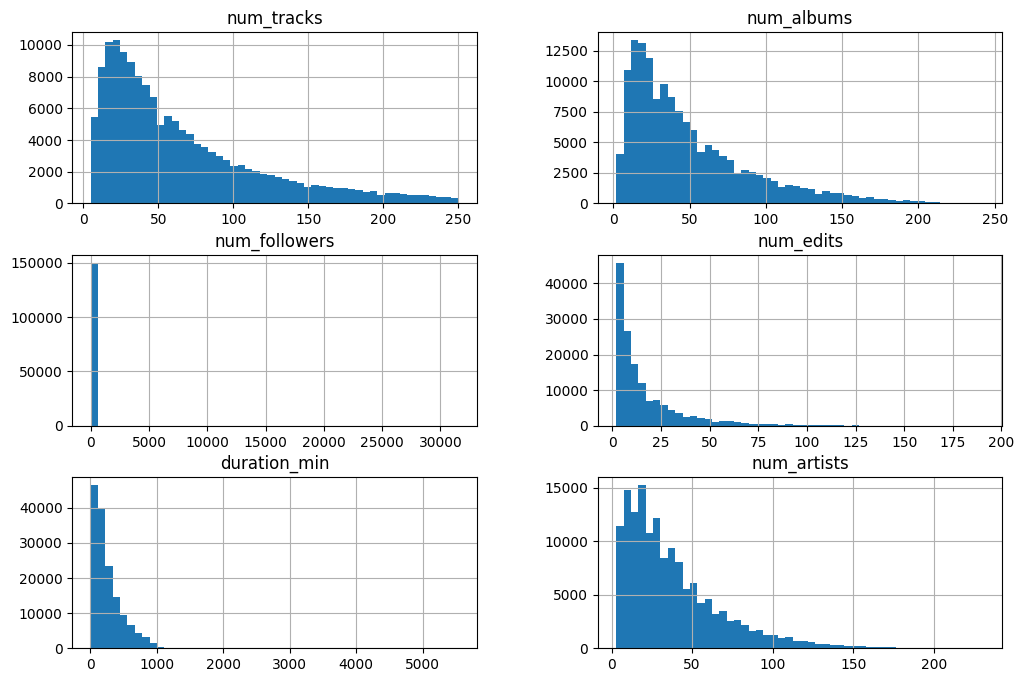

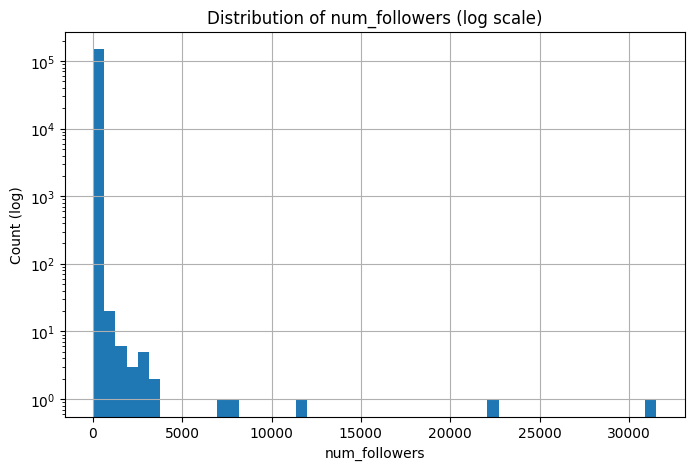

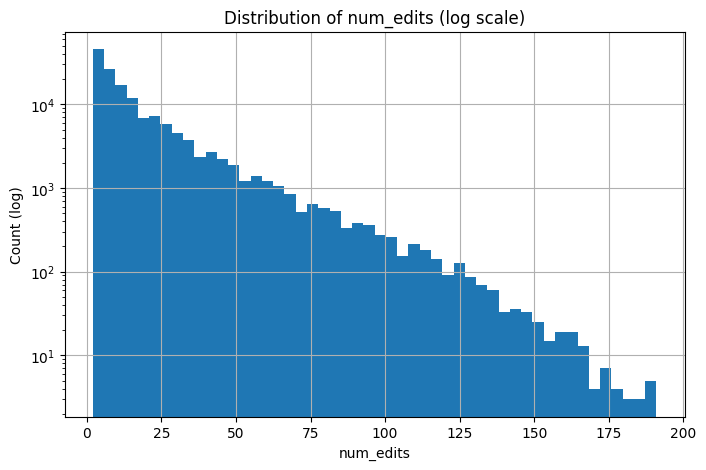

In [6]:
import matplotlib.pyplot as plt

# Numeric statistics
df.describe()

# Convert duration from milliseconds to minutes for better interpretability
df['duration_min'] = df['duration_ms'] / 60000

# Histograms for numerical features
numeric_cols = ['num_tracks','num_albums','num_followers','num_edits','duration_min','num_artists']
df[numeric_cols].hist(bins=50, figsize=(12,8))
plt.show()

# Log-scaled histograms for skewed features
for col in ['num_followers','num_edits']:
    plt.figure(figsize=(8,5))
    df[col].hist(bins=50, log=True)
    plt.title(f"Distribution of {col} (log scale)")
    plt.xlabel(col)
    plt.ylabel("Count (log)")
    plt.show()


### 4.4 Playlist Characteristics
#### 4.4.1 Collaborative vs Non-Collaborative

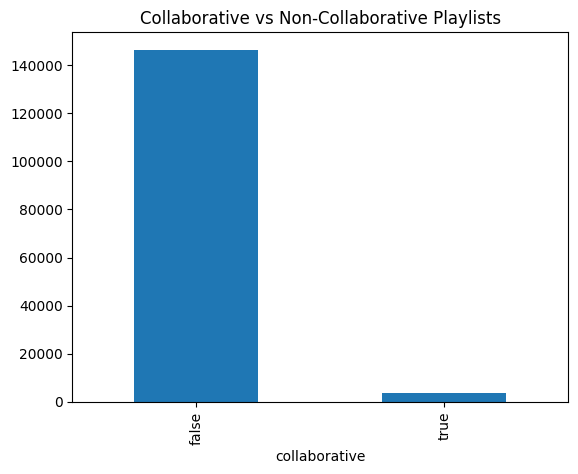

,num_tracks,num_followers
collaborative,,
false,66.435198,2.591230
true,74.901582,1.644405


In [7]:
df['collaborative'].value_counts().plot(kind='bar', title='Collaborative vs Non-Collaborative Playlists')
plt.show()

# Average number of tracks and followers by collaborative status
collab_counts = df.groupby('collaborative')[['num_tracks','num_followers']].mean()
display(collab_counts)

#### 4.4.2 Playlist Length Distribution

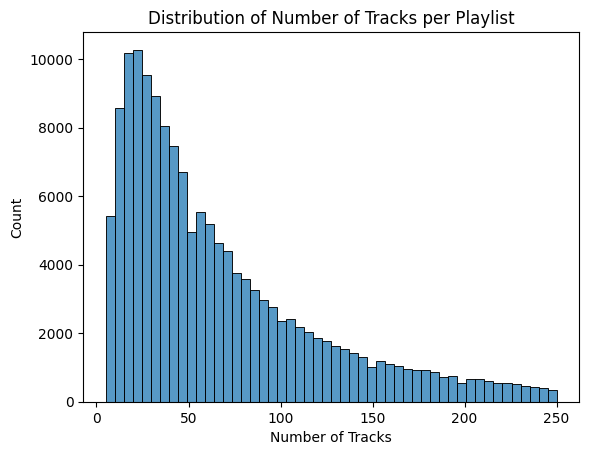

In [8]:
import seaborn as sns

sns.histplot(df['num_tracks'], bins=50)
plt.title("Distribution of Number of Tracks per Playlist")
plt.xlabel("Number of Tracks")
plt.show()

#### 4.4.3 Playlist Duration

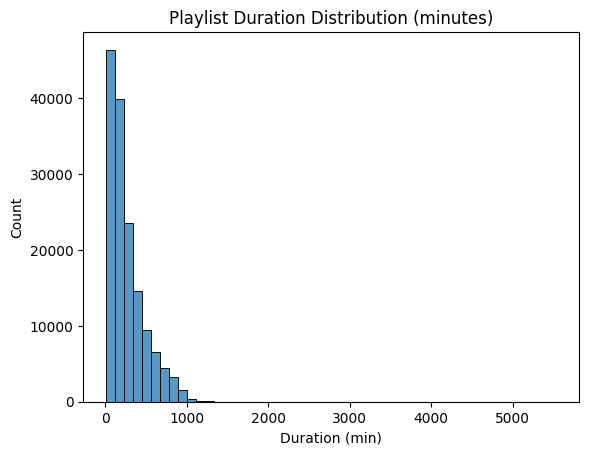

In [9]:
sns.histplot(df['duration_min'], bins=50)
plt.title("Playlist Duration Distribution (minutes)")
plt.xlabel("Duration (min)")
plt.show()

### 4.5 Track & Artist Popularity
#### 4.5.1 Top 20 artists

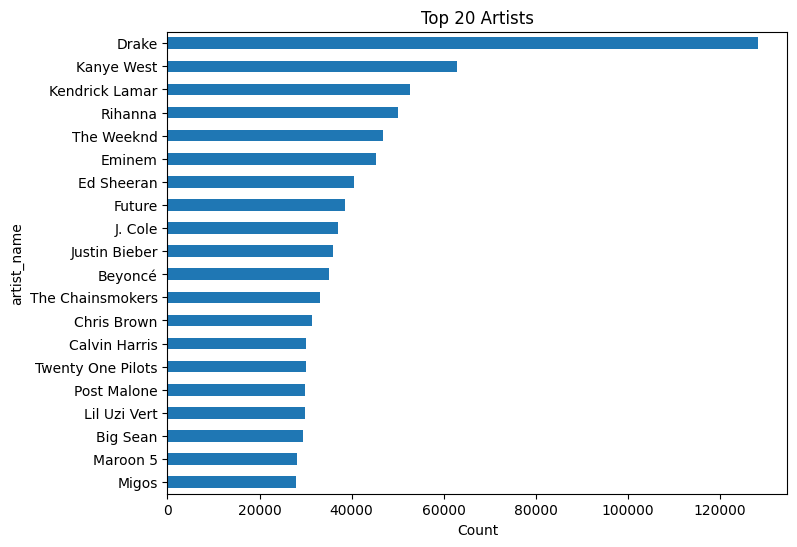

In [10]:
top_artists = tracks_df['artist_name'].value_counts().head(20)
plt.figure(figsize=(8,6))
top_artists.plot(kind='barh', title='Top 20 Artists')
plt.gca().invert_yaxis()
plt.xlabel("Count")
plt.show()

#### 4.5.2 Top 20 tracks

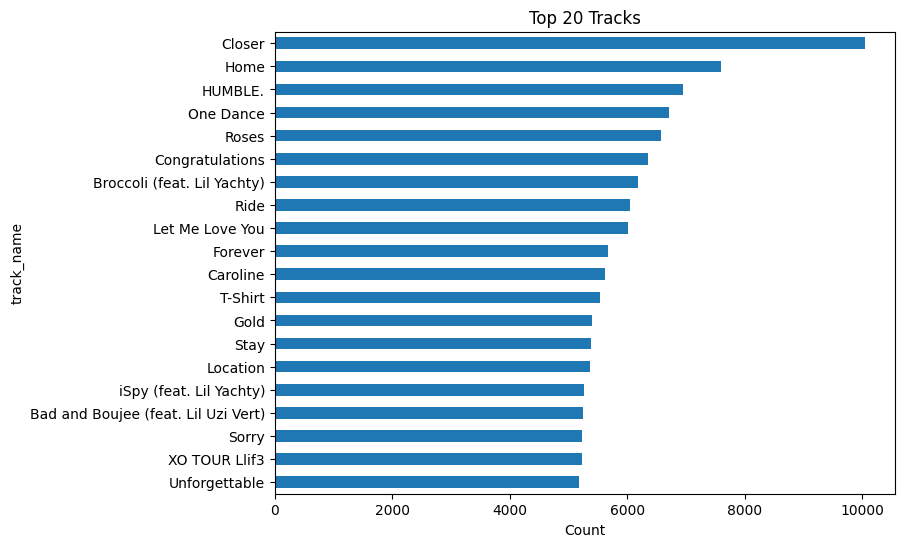

In [11]:
top_tracks = tracks_df['track_name'].value_counts().head(20)
plt.figure(figsize=(8,6))
top_tracks.plot(kind='barh', title='Top 20 Tracks')
plt.gca().invert_yaxis()
plt.xlabel("Count")
plt.show()